In [2]:
import numpy as np
import pandas as pd
import warnings
import anndata as ad
from torch.utils.data import Dataset

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# batch_csv = "/net/seq/data2/projects/mbrannon/variant_model_test/2026_02_03_admiring_curie/batch_logs/batch_debug.csv"
batch_csv = "/net/seq/data2/projects/mbrannon/variant_model_test/2026_03_12_elastic_bohr/batch_logs/batch_debug.csv"
metrics_csv = "/net/seq/data2/projects/mbrannon/variant_model_test/2026_03_12_elastic_bohr/logs/lightning_logs/version_0/metrics.csv"
### good
metrics_csv = '/net/seq/data2/projects/mbrannon/variant_model_test/2026_03_12_elastic_bohr/logs/lightning_logs/version_0/metrics.csv'
batch_df = pd.read_csv(batch_csv)
metrics_df = pd.read_csv(metrics_csv)


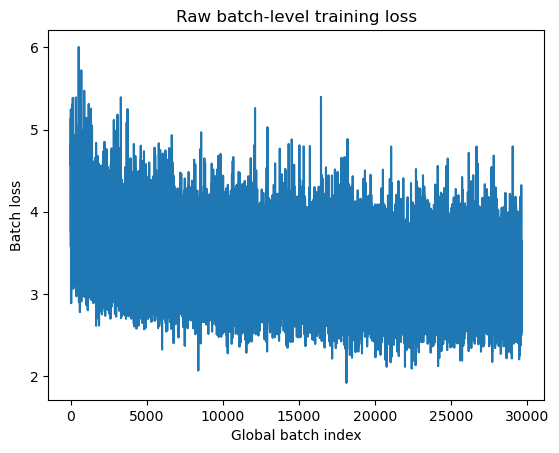

In [4]:
batch_df["global_batch"] = range(len(batch_df))

plt.figure()
plt.plot(batch_df["global_batch"], batch_df["loss"])
plt.xlabel("Global batch index")
plt.ylabel("Batch loss")
plt.title("Raw batch-level training loss")
plt.show()


In [5]:

batch_df

,epoch,batch_idx,loss,min_lfc,max_lfc,min_ref_counts,max_ref_counts,min_total_counts,max_total_counts,min_bad_score,max_bad_score,global_batch
0,0,0,4.812062,-3.418987,1.966392,1.0,402.0,35.0,777.0,1.0,4.0,0
1,0,0,5.003934,-2.362046,2.396605,3.0,454.0,35.0,858.0,1.0,6.0,1
2,0,0,4.803144,-2.971763,2.469531,2.0,337.0,35.0,731.0,1.0,3.0,2
3,0,0,4.567078,-3.351914,2.873319,1.0,526.0,35.0,909.0,1.0,4.0,3
4,0,0,4.817672,-2.959366,2.735431,1.0,367.0,35.0,682.0,1.0,5.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...
29635,14,246,2.980182,-3.365913,3.904715,1.0,337.0,35.0,729.0,1.0,5.0,29635
29636,14,246,2.782887,-2.421626,3.292651,2.0,396.0,35.0,771.0,1.0,6.0,29636
29637,14,246,2.709258,-3.030794,2.830039,1.0,432.0,35.0,811.0,1.0,3.0,29637
29638,14,246,3.183307,-2.784174,2.568160,2.0,292.0,35.0,506.0,1.0,3.0,29638


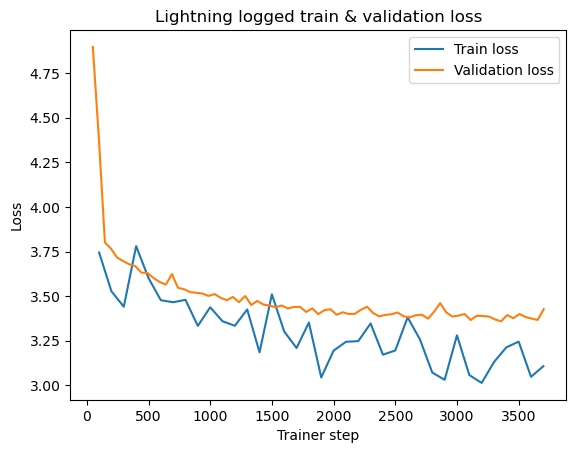

In [6]:
train_loss_df = metrics_df.dropna(subset=["loss"])
val_loss_df = metrics_df.dropna(subset=["val_loss"])

plt.figure()
plt.plot(
    train_loss_df["step"],
    train_loss_df["loss"],
    label="Train loss"
)
plt.plot(
    val_loss_df["step"],
    val_loss_df["val_loss"],
    label="Validation loss"
)

plt.xlabel("Trainer step")
plt.ylabel("Loss")
plt.title("Lightning logged train & validation loss")
plt.legend()
plt.show()


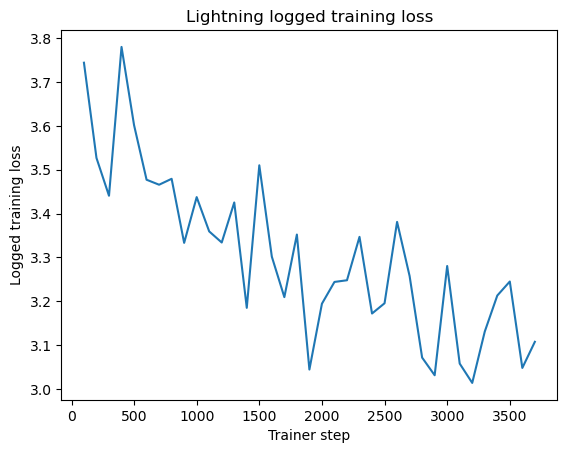

In [7]:
train_loss_df = metrics_df.dropna(subset=["loss"])

plt.figure()
plt.plot(train_loss_df["step"], train_loss_df["loss"])
plt.xlabel("Trainer step")
plt.ylabel("Logged training loss")
plt.title("Lightning logged training loss")
plt.show()


In [8]:
metrics_df

,epoch,loss,lr-AdamW,step,val_loss,val_pcc
0,NaN,NaN,0.00001,0,NaN,NaN
1,0.0,NaN,NaN,48,4.896488,0.459299
2,0.0,NaN,NaN,97,4.384143,0.469077
3,NaN,NaN,0.00001,99,NaN,NaN
4,0.0,3.744126,NaN,99,NaN,NaN
...,...,...,...,...,...,...
159,14.0,NaN,NaN,3604,3.374337,0.554493
160,14.0,NaN,NaN,3653,3.366595,0.553715
161,NaN,NaN,0.00001,3699,NaN,NaN
162,14.0,3.107382,NaN,3699,NaN,NaN


In [9]:
metrics_df

,epoch,loss,lr-AdamW,step,val_loss,val_pcc
0,NaN,NaN,0.00001,0,NaN,NaN
1,0.0,NaN,NaN,48,4.896488,0.459299
2,0.0,NaN,NaN,97,4.384143,0.469077
3,NaN,NaN,0.00001,99,NaN,NaN
4,0.0,3.744126,NaN,99,NaN,NaN
...,...,...,...,...,...,...
159,14.0,NaN,NaN,3604,3.374337,0.554493
160,14.0,NaN,NaN,3653,3.366595,0.553715
161,NaN,NaN,0.00001,3699,NaN,NaN
162,14.0,3.107382,NaN,3699,NaN,NaN


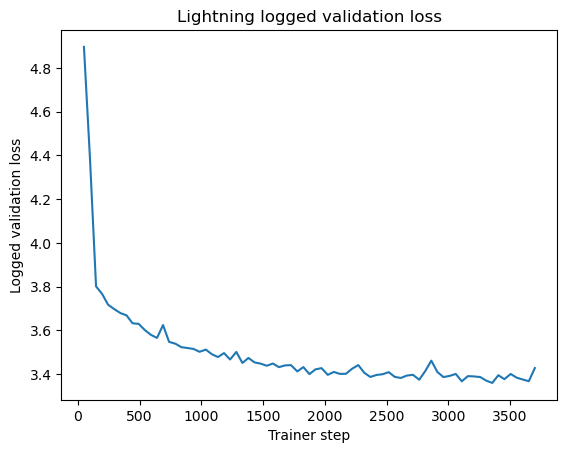

In [10]:
val_loss_df = metrics_df.dropna(subset=["val_loss"])

plt.figure()
plt.plot(val_loss_df["step"], val_loss_df["val_loss"])
plt.xlabel("Trainer step")
plt.ylabel("Logged validation loss")
plt.title("Lightning logged validation loss")
plt.show()


In [11]:
train_loss_df

,epoch,loss,lr-AdamW,step,val_loss,val_pcc
4,0.0,3.744126,NaN,99,NaN,NaN
8,0.0,3.526852,NaN,199,NaN,NaN
13,1.0,3.440599,NaN,299,NaN,NaN
17,1.0,3.780142,NaN,399,NaN,NaN
22,2.0,3.601746,NaN,499,NaN,NaN
26,2.0,3.477164,NaN,599,NaN,NaN
30,2.0,3.465764,NaN,699,NaN,NaN
35,3.0,3.479277,NaN,799,NaN,NaN
39,3.0,3.333118,NaN,899,NaN,NaN
44,4.0,3.437497,NaN,999,NaN,NaN
